In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
from IPython.display import Image
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_columns', None)

In [2]:
df_inventory = pd.read_csv('../data/inventory.csv')
df_orders = pd.read_csv('../data/orders.csv')
df_order_items = pd.read_csv('../data/order_items.csv', dtype={'promo_id_2': str})
df_products = pd.read_csv('../data/products.csv')

In [3]:
print("--- Inventory Null Counts ---")
print(df_inventory.isnull().sum())

print("\n--- Orders Null Counts ---")
print(df_orders.isnull().sum())

print("\n--- Order Items Null Counts ---")
print(df_order_items.isnull().sum())

print("\n--- Products Null Counts ---")
print(df_products.isnull().sum())

--- Inventory Null Counts ---
snapshot_date        0
product_id           0
stock_on_hand        0
units_received       0
units_sold           0
stockout_days        0
days_of_supply       0
fill_rate            0
stockout_flag        0
overstock_flag       0
reorder_flag         0
sell_through_rate    0
product_name         0
category             0
segment              0
year                 0
month                0
dtype: int64

--- Orders Null Counts ---
order_id          0
order_date        0
customer_id       0
zip               0
order_status      0
payment_method    0
device_type       0
order_source      0
dtype: int64

--- Order Items Null Counts ---
order_id                0
product_id              0
quantity                0
unit_price              0
discount_amount         0
promo_id           438353
promo_id_2         714463
dtype: int64

--- Products Null Counts ---
product_id      0
product_name    0
category        0
segment         0
size            0
color           0

In [4]:
df_order_items['promo_id'] = df_order_items['promo_id'].fillna('NO_PROMO')
df_order_items['promo_id_2'] = df_order_items['promo_id_2'].fillna('NO_PROMO')

df_order_items

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NO_PROMO,NO_PROMO
1,2,609,7,10166.25,0.0,NO_PROMO,NO_PROMO
2,3,396,3,11220.33,0.0,NO_PROMO,NO_PROMO
3,4,635,5,10639.25,0.0,NO_PROMO,NO_PROMO
4,6,1935,1,1597.84,0.0,NO_PROMO,NO_PROMO
...,...,...,...,...,...,...,...
714664,834372,690,8,4473.92,0.0,NO_PROMO,NO_PROMO
714665,834377,1995,7,5250.79,0.0,NO_PROMO,NO_PROMO
714666,834387,2331,8,7389.06,0.0,NO_PROMO,NO_PROMO
714667,834392,1115,5,4767.33,0.0,NO_PROMO,NO_PROMO


ERD diagram:


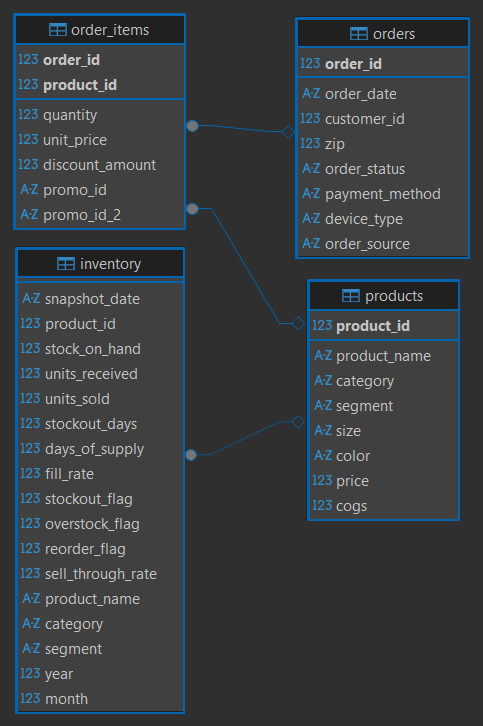

In [5]:
print('ERD diagram:')

Image("/mnt/c/Users/Admin/Downloads/DATATHON.PNG")

In [6]:
df_merged_table1 = df_order_items.merge(df_orders, on='order_id', how='left')

df_merged_table2 = df_merged_table1.merge(df_products, on='product_id', how='left')

df_merged_table2

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_name,category,segment,size,color,price,cogs
0,1,2400,7,1138.22,0.0,NO_PROMO,NO_PROMO,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008
1,2,609,7,10166.25,0.0,NO_PROMO,NO_PROMO,2012-07-04,58621,1330,returned,cod,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231
2,3,396,3,11220.33,0.0,NO_PROMO,NO_PROMO,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256
3,4,635,5,10639.25,0.0,NO_PROMO,NO_PROMO,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,10745.220588,9205.430478
4,6,1935,1,1597.84,0.0,NO_PROMO,NO_PROMO,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1609.911509,1048.696357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714664,834372,690,8,4473.92,0.0,NO_PROMO,NO_PROMO,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign,SaigonFlex UC-55,Streetwear,Everyday,L,red,4598.817231,3100.062695
714665,834377,1995,7,5250.79,0.0,NO_PROMO,NO_PROMO,2022-12-31,73046,37091,delivered,credit_card,mobile,referral,UrbanVN UM-02,Streetwear,Balanced,XL,purple,5159.312851,3025.421056
714666,834387,2331,8,7389.06,0.0,NO_PROMO,NO_PROMO,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign,VietMotion UE-05,Streetwear,Performance,XL,black,7365.661770,6671.816431
714667,834392,1115,5,4767.33,0.0,NO_PROMO,NO_PROMO,2022-12-31,139431,93510,delivered,paypal,desktop,direct,MekongFit RS-03,Outdoor,Premium,XL,purple,4828.925117,4587.478861


In [7]:
df_merged_table2['unit_price'] = pd.to_numeric(df_merged_table2['unit_price'], errors='coerce')
df_merged_table2['quantity'] = pd.to_numeric(df_merged_table2['quantity'], errors='coerce')
df_merged_table2['cogs'] = pd.to_numeric(df_merged_table2['cogs'], errors='coerce')

df_merged_table2['total_revenue'] = df_merged_table2['unit_price'] * df_merged_table2['quantity']
df_merged_table2['total_cost'] = df_merged_table2['cogs'] * df_merged_table2['quantity']
df_merged_table2['total_profit'] = df_merged_table2['total_revenue'] - df_merged_table2['total_cost']
df_merged_table2['profit_margin'] = (df_merged_table2['total_profit'] / df_merged_table2['total_revenue']) * 100

df_merged_table2

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_name,category,segment,size,color,price,cogs,total_revenue,total_cost,total_profit,profit_margin
0,1,2400,7,1138.22,0.0,NO_PROMO,NO_PROMO,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008,7967.54,7376.586059,590.953941,7.417019
1,2,609,7,10166.25,0.0,NO_PROMO,NO_PROMO,2012-07-04,58621,1330,returned,cod,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231,71163.75,62913.929616,8249.820384,11.592729
2,3,396,3,11220.33,0.0,NO_PROMO,NO_PROMO,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256,33660.99,30273.036767,3387.953233,10.064925
3,4,635,5,10639.25,0.0,NO_PROMO,NO_PROMO,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,10745.220588,9205.430478,53196.25,46027.152390,7169.097610,13.476697
4,6,1935,1,1597.84,0.0,NO_PROMO,NO_PROMO,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1609.911509,1048.696357,1597.84,1048.696357,549.143643,34.367874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714664,834372,690,8,4473.92,0.0,NO_PROMO,NO_PROMO,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign,SaigonFlex UC-55,Streetwear,Everyday,L,red,4598.817231,3100.062695,35791.36,24800.501564,10990.858436,30.708133
714665,834377,1995,7,5250.79,0.0,NO_PROMO,NO_PROMO,2022-12-31,73046,37091,delivered,credit_card,mobile,referral,UrbanVN UM-02,Streetwear,Balanced,XL,purple,5159.312851,3025.421056,36755.53,21177.947390,15577.582610,42.381602
714666,834387,2331,8,7389.06,0.0,NO_PROMO,NO_PROMO,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign,VietMotion UE-05,Streetwear,Performance,XL,black,7365.661770,6671.816431,59112.48,53374.531451,5737.948549,9.706831
714667,834392,1115,5,4767.33,0.0,NO_PROMO,NO_PROMO,2022-12-31,139431,93510,delivered,paypal,desktop,direct,MekongFit RS-03,Outdoor,Premium,XL,purple,4828.925117,4587.478861,23836.65,22937.394304,899.255696,3.772576


In [8]:
categorical_cols = [
    'payment_method', 'order_status', 'order_source', 'device_type', 
    'category', 'segment', 'zip', 'promo_id', 'promo_id_2', 'customer_id', 'product_id'
]

for col in categorical_cols:
    if col in df_merged_table2.columns:
        df_count = df_merged_table2[col].value_counts().sort_values(ascending=False).reset_index()
        df_count.columns = [col.capitalize(), 'Count']
        
        # Saves the variable (e.g., payment_method_count)
        globals()[f"{col}_count"] = df_count
        
        print(f"\n--- {col}_count ---")
        display(df_count)


--- payment_method_count ---


,Payment_method,Count
0,credit_card,393421
1,paypal,107230
2,cod,106965
3,apple_pay,71510
4,bank_transfer,35543



--- order_status_count ---


,Order_status,Count
0,delivered,570887
1,cancelled,65673
2,returned,40034
3,shipped,15094
4,paid,14987
5,created,7994



--- order_source_count ---


...

,Promo_id_2,Count
0,NO_PROMO,714463
1,PROMO-0015,132
2,PROMO-0025,74



--- customer_id_count ---


,Customer_id,Count
0,139050,128
1,141898,128
2,141899,127
3,139138,121
4,141897,120
...,...,...
90241,123381,1
90242,94649,1
90243,86639,1
90244,123517,1



--- product_id_count ---


,Product_id,Count
0,792,10160
1,791,10140
2,604,8115
3,2045,7925
4,487,7418
...,...,...
1593,1469,1
1594,1487,1
1595,1488,1
1596,1602,1


<Figure size 1000x500 with 0 Axes>

Text(0.5, 1.0, 'Total Profit by Segment')

Text(0.5, 0, 'Segment')

Text(0, 0.5, 'Total Profit')

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Everyday'),
  Text(1, 0, 'Balanced'),
  Text(2, 0, 'Activewear'),
  Text(3, 0, 'Performance'),
  Text(4, 0, 'Trendy'),
  Text(5, 0, 'Premium'),
  Text(6, 0, 'All-weather'),
  Text(7, 0, 'Standard')])

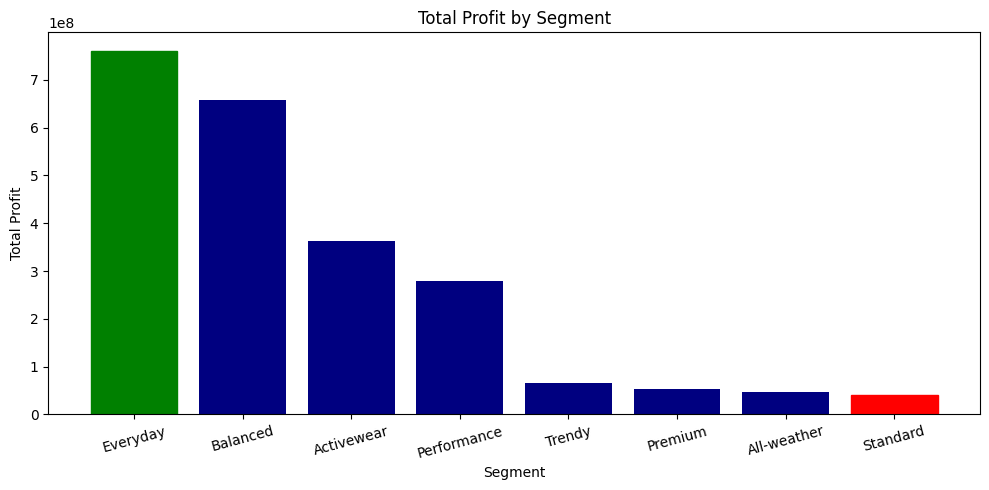

In [9]:
#Highest, lowest profit by segment

import matplotlib.pyplot as plt

segment_profit = df_merged_table2.groupby('segment')['total_profit'].sum().reset_index()
segment_profit = segment_profit.sort_values('total_profit', ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(segment_profit['segment'], segment_profit['total_profit'], color='navy')

bars[0].set_color('green')
bars[-1].set_color('red')

plt.title('Total Profit by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Profit')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Correlation Matrix:
total_profit    1.000000
unit_price      0.373198
quantity        0.229876
Name: total_profit, dtype: float64


<Axes: >

Text(0.5, 1.0, 'Correlation: Price & Quantity vs Profit')

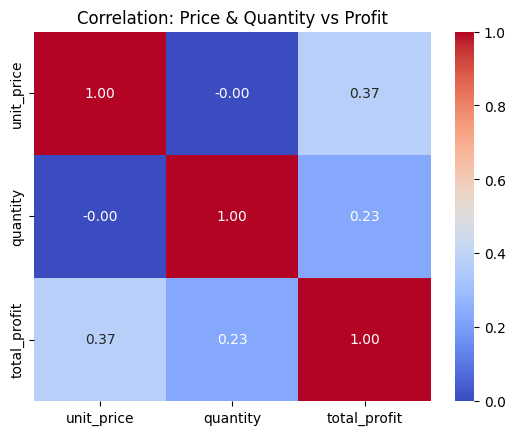

<Axes: xlabel='unit_price', ylabel='total_profit'>

Text(0.5, 1.0, 'Does Price Drive Profit?')

<Axes: xlabel='quantity', ylabel='total_profit'>

Text(0.5, 1.0, 'Does Quantity Drive Profit?')

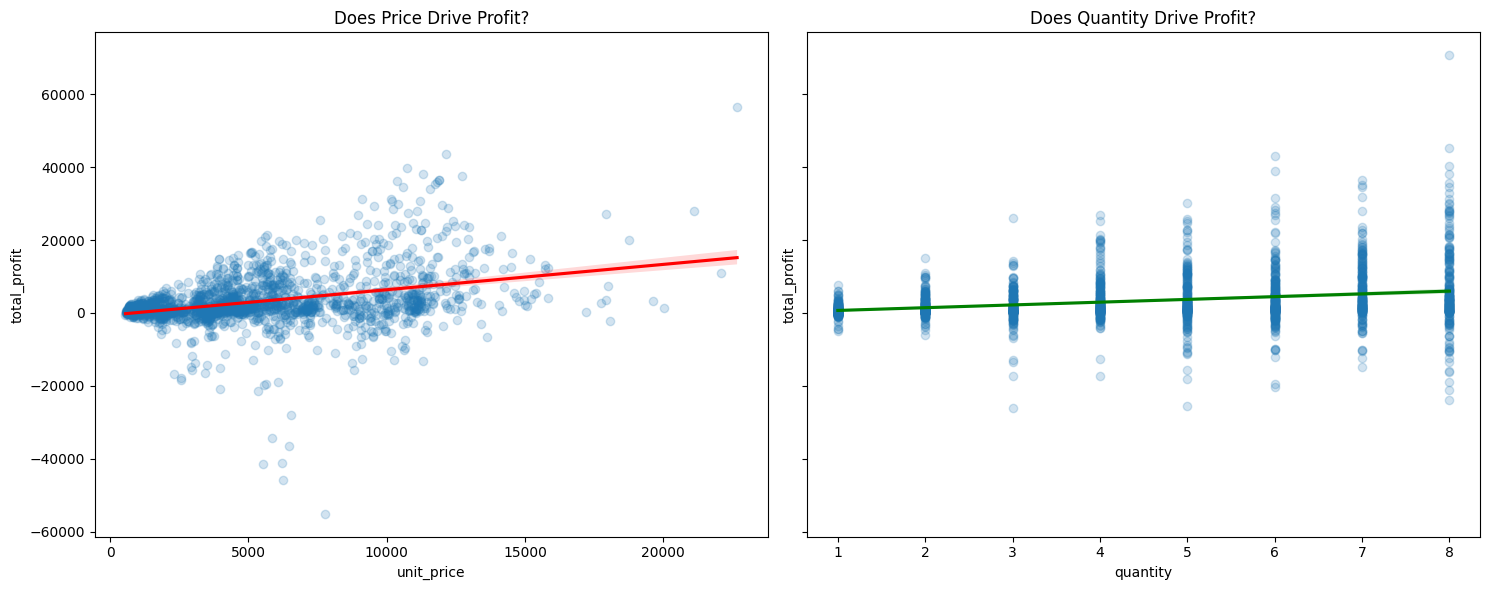

In [10]:
#Correlation of Price and Profit vs correlation of quantity and profit

correlation_data = df_merged_table2[['unit_price', 'quantity', 'total_profit']]
matrix = correlation_data.corr()

print("Correlation Matrix:")
print(matrix['total_profit'].sort_values(ascending=False))

sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation: Price & Quantity vs Profit')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plot 1: Price vs Profit
sns.regplot(data=df_merged_table2.sample(2000), x='unit_price', y='total_profit', 
            ax=ax1, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
ax1.set_title('Does Price Drive Profit?')

# Plot 2: Quantity vs Profit
sns.regplot(data=df_merged_table2.sample(2000), x='quantity', y='total_profit', 
            ax=ax2, scatter_kws={'alpha':0.2}, line_kws={'color':'green'})
ax2.set_title('Does Quantity Drive Profit?')

plt.tight_layout()
plt.show()

In [11]:
# Does promotion results in higher

df_merged_table2['is_promo'] = ~(
    (df_merged_table2['promo_id'] == 'NO_PROMO') &
    (df_merged_table2['promo_id_2'] == 'NO_PROMO')
)
